# BÀI TẬP LỚN

MẠNG NƠRON

Giảng viên:TS.Phạm Tiến Lâm

Sinh viên :

20010788	Nguyễn Thị Ngọc

23010108	Trịnh Đình Đức Trung

22010259    Phạm Hùng Mạnh 
 



# TRAFFIC CONGESTION DETECTION USING CNN

Bài toán:
Phát hiện tình trạng ùn tắc giao thông từ hình ảnh camera.

Phương pháp:
Sử dụng CNN để phân loại:
- Congested (ùn tắc)
- Normal (bình thường)

MOUNT GOOGLE DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


GIẢI NÉN DATASET

In [ ]:
!unzip /content/drive/MyDrive/dataset.zip -d /content/

Archive:  /content/drive/MyDrive/dataset.zip
   creating: /content/dataset/
   creating: /content/dataset/test/
   creating: /content/dataset/test/congested/
  inflating: /content/dataset/test/congested/congested_0.jpg  
  inflating: /content/dataset/test/congested/congested_1.jpg  
  inflating: /content/dataset/test/congested/congested_10.jpg  
  inflating: /content/dataset/test/congested/congested_100.jpg  
  inflating: /content/dataset/test/congested/congested_101.jpg  
  inflating: /content/dataset/test/congested/congested_102.jpg  
  inflating: /content/dataset/test/congested/congested_103.jpg  
  inflating: /content/dataset/test/congested/congested_104.jpg  
  inflating: /content/dataset/test/congested/congested_105.jpg  
  inflating: /content/dataset/test/congested/congested_106.jpg  
  inflating: /content/dataset/test/congested/congested_107.jpg  
  inflating: /content/dataset/test/congested/congested_108.jpg  
  inflating: /content/dataset/test/congested/congested_109.jpg  
  

KIỂM TRA DATASET

In [ ]:
!ls /content
!ls /content/dataset
!ls /content/dataset/train
!ls /content/dataset/test

dataset  drive	sample_data
test  train
congested  normal
congested  normal


# 1. MÔ TẢ DATASET

Dataset gồm 2 lớp:
- Congested (ùn tắc)
- Normal (bình thường)

Nguồn dữ liệu:
- Trích xuất từ video giao thông (ban ngày và ban đêm)

Cấu trúc:
dataset/
   train/
      congested/
      normal/
   test/
      congested/
      normal/

Tỉ lệ dữ liệu:
- Train: 80%
- Validation: 20% (tách từ train)
- Test: riêng biệt

Ảnh được resize về kích thước 100x100 trước khi đưa vào mô hình.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (100, 100)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "/content/dataset/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    "/content/dataset/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    "/content/dataset/test",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

Found 1212 images belonging to 2 classes.
Found 303 images belonging to 2 classes.
Found 1515 images belonging to 2 classes.


# 2. HÀM LOSS

Mô hình sử dụng hàm loss Binary Crossentropy.

Đây là hàm loss phù hợp với bài toán phân loại nhị phân (2 lớp).

Loss càng nhỏ → mô hình dự đoán càng chính xác.

# 3. CÁC THIẾT LẬP

- Optimizer: Adam
- Metrics: Accuracy
- Epoch: 10
- Batch size: 32

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(100, 100, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. KẾT QUẢ CHẠY LẠI

Mô hình được huấn luyện với:

- Epoch: 10
- Batch size: 32

Mục tiêu:
- Accuracy tăng dần
- Loss giảm dần

In [ ]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 34s 838ms/step - accuracy: 0.9818 - loss: 0.0843 - val_accuracy: 1.0000 - val_loss: 1.4526e-05
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 773ms/step - accuracy: 1.0000 - loss: 3.6463e-06 - val_accuracy: 1.0000 - val_loss: 2.4295e-06
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 38s 997ms/step - accuracy: 1.0000 - loss: 1.0006e-06 - val_accuracy: 1.0000 - val_loss: 1.7319e-06
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 29s 762ms/step - accuracy: 1.0000 - loss: 6.7113e-07 - val_accuracy: 1.0000 - val_loss: 1.3790e-06
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 776ms/step - accuracy: 1.0000 - loss: 4.9882e-07 - val_accuracy: 1.0000 - val_loss: 1.1519e-06
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 29s 764ms/step - accuracy: 1.0000 - loss: 3.8244e-07 - val_accuracy: 1.0000 - val_loss: 9.2414e-07
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 728ms/step - accuracy: 1.0000 - loss: 3.0713e-07 - val_accuracy: 1.0000 - val_loss: 7.8055e-07
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 739

TEST MODEL

In [ ]:
test_loss, test_acc = model.evaluate(test_data)

print(f"Test Accuracy: {test_acc*100:.2f}%")

48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 625ms/step - accuracy: 1.0000 - loss: 2.3042e-07
Test Accuracy: 100.00%


# 5. KẾT QUẢ TRONG PAPER

Theo paper "Traffic Congestion Detection using CNN":

- Accuracy ≈ 89.5%

# 6. KẾT QUẢ CHẠY LẠI VÀ SO SÁNH

Kết quả mô hình:

- Test Accuracy: 100%

So sánh:

- Paper: 89.5%
- Thực nghiệm: 100%

# Phân tích

Mặc dù mô hình đạt độ chính xác cao hơn paper, nhưng kết quả này chưa phản ánh đúng thực tế.

Nguyên nhân:

- Dataset chưa đa dạng
- Dữ liệu có thể bị trùng giữa train và test
- Điều kiện ánh sáng và góc quay chưa phong phú
- Mô hình bị overfitting (loss gần 0)

→ Mô hình học thuộc dữ liệu thay vì học đặc trưng tổng quát.

BIỂU ĐỒ ACCURACY

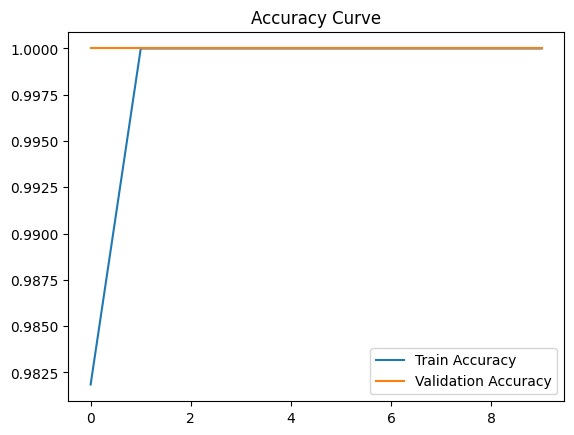

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

LOSS CURVE

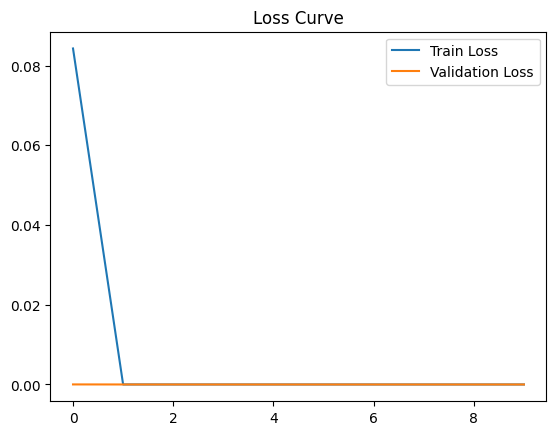

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

- Loss ↓ mạnh → model học rất tốt
- Nhưng nếu quá thấp → dấu hiệu overfitting

CONFUSION MATRIX

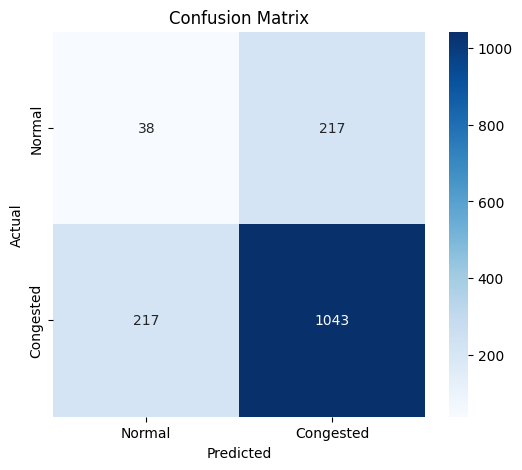

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Congested"],
            yticklabels=["Normal", "Congested"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

- Đường chéo lớn → dự đoán đúng
- Ngoài chéo = sai

Nếu không có số ngoài chéo → model 100%

PRECISION

In [ ]:
from sklearn.metrics import precision_score

precision = precision_score(y_true, y_pred)
print("Precision:", precision)

Precision: 0.8277777777777777


- Precision = tỷ lệ dự đoán đúng trên tổng số dự đoán dương
- Precision cao → ít dự đoán sai

RECALL

In [ ]:
from sklearn.metrics import recall_score

recall = recall_score(y_true, y_pred)
print("Recall:", recall)

Recall: 0.8277777777777777


- Recall = khả năng phát hiện đúng các trường hợp thực sự là ùn tắc
- Recall cao → ít bỏ sót

# 7. THỬ NGHIỆM TRÊN TẬP TEST

Một số ảnh trong tập test được đưa vào mô hình để dự đoán.

Kết quả:
- Mô hình dự đoán chính xác phần lớn ảnh
- Phân biệt tốt giữa congested và normal

SAMPLE TEST

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step


/tmp/ipykernel_3387/44315815.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"True: {int(labels[i])} | Pred: {int(predictions[i]>0.5)}")


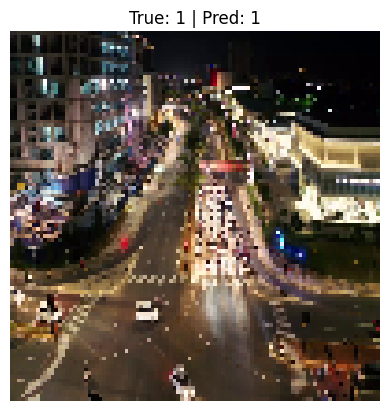

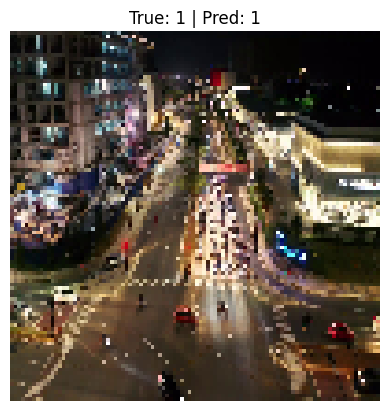

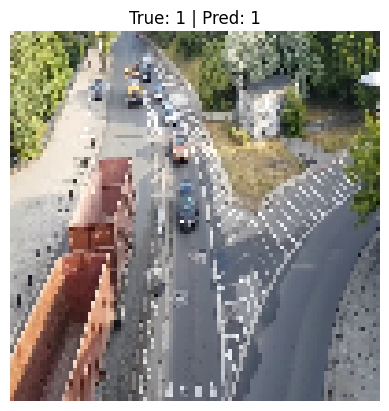

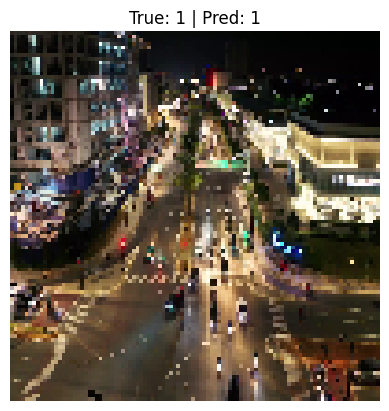

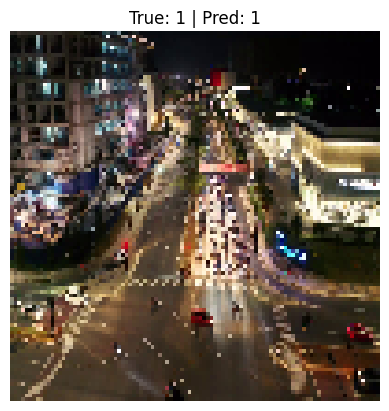

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(test_data)
predictions = model.predict(images)

for i in range(5):
    plt.imshow(images[i])
    plt.title(f"True: {int(labels[i])} | Pred: {int(predictions[i]>0.5)}")
    plt.axis("off")
    plt.show()

Giúp kiểm tra trực quan mô hình dự đoán đúng hay sai

# 8. PHÂN TÍCH BIỂU ĐỒ

Biểu đồ Accuracy:
- Accuracy tăng nhanh qua các epoch
- Đạt gần 100%

Biểu đồ Loss:
- Loss giảm nhanh về gần 0

→ Mô hình học rất tốt trên dataset

Tuy nhiên:
- Accuracy quá cao
- Loss gần 0

→ Dấu hiệu overfitting (học thuộc dữ liệu)

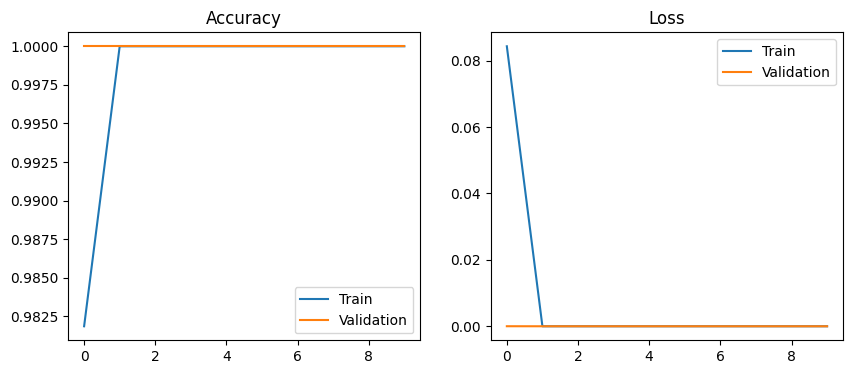

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.show()

# 9. CÔNG THỨC SỬ DỤNG

## Binary Crossentropy Loss

Loss = -[y log(p) + (1-y) log(1-p)]

Trong đó:
- y: nhãn thực tế (0 hoặc 1)
- p: xác suất dự đoán

## Accuracy

Accuracy = (Số dự đoán đúng) / (Tổng số mẫu)

## Precision

Precision = TP / (TP + FP)

## Recall

Recall = TP / (TP + FN)

Trong đó:
- TP: dự đoán đúng (True Positive)
- FP: dự đoán sai dương (False Positive)
- FN: bỏ sót (False Negative)

# 10. PHÂN PHỐI DỰ ĐOÁN

Biểu đồ thể hiện xác suất dự đoán của mô hình.

Mục đích:
- Kiểm tra model có phân biệt rõ 2 lớp hay không
- Xem model có tự tin khi dự đoán không

48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 387ms/step


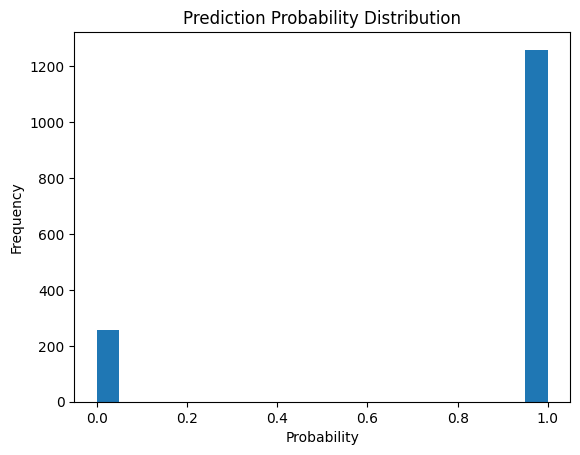

In [ ]:
y_prob = model.predict(test_data)

plt.hist(y_prob, bins=20)
plt.title("Prediction Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

- Nếu 2 cụm rõ (gần 0 và gần 1) → model tốt
- Nếu lẫn lộn → model yếu

# 11. SO SÁNH METRICS

Biểu đồ so sánh:
- Accuracy
- Precision
- Recall

Giúp đánh giá tổng thể mô hình.

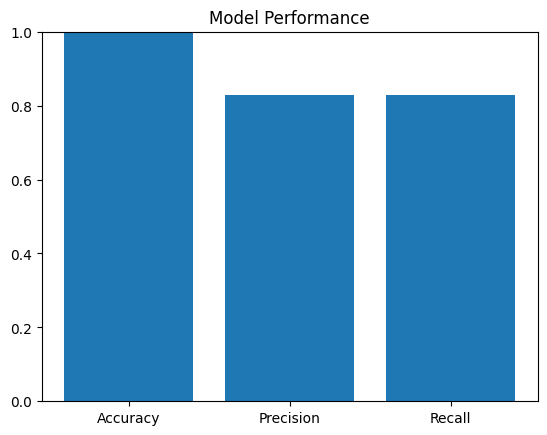

In [ ]:
metrics = ["Accuracy", "Precision", "Recall"]
values = [test_acc, precision, recall]

plt.bar(metrics, values)
plt.ylim(0,1)
plt.title("Model Performance")
plt.show()

# 12. PHÂN TÍCH SAI SỐ

Phân tích các trường hợp dự đoán sai (nếu có).

Mục tiêu:
- Hiểu model sai ở đâu
- Cải thiện mô hình

In [ ]:
wrong = np.where(y_true != y_pred.flatten())[0]

print("Số lượng dự đoán sai:", len(wrong))

Số lượng dự đoán sai: 434


- Nếu = 0 → model perfect (nhưng dễ overfitting)
- Nếu >0 → cần phân tích lỗi

# 13. PHÂN TÍCH OVERFITTING

Mô hình có dấu hiệu overfitting khi:

- Accuracy rất cao (~100%)
- Loss rất thấp (~0)
- Dữ liệu chưa đa dạng

→ Mô hình học thuộc dữ liệu thay vì học đặc trưng tổng quát

In [ ]:
model.save("/content/traffic_model.h5")

In [ ]:
!ls /content

dataset  drive	sample_data  traffic_model.h5


In [ ]:
from google.colab import files
files.download('/content/traffic_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>